In [1]:
import numpy as np
import pandas as pd

from pyboat import ensemble_measures as em
from pyboat import WAnalyzer, ssg
from pyboat import plotting as pl

import scipy.signal
import pywt

import matplotlib.pyplot as plt

import bokeh_catplot
from bokeh.plotting import figure, show
from bokeh.models import FactorRange, Button, ColumnDataSource, HoverTool, TapTool, Slider, Select, Span, BoxZoomTool

import bokeh.io

import iqplot

bokeh.io.output_notebook()

C:\Users\pperez\.conda\envs\devbio-napari-cupy\lib\site-packages\bokeh_catplot\__init__.py:13: DeprecationWarning: bokeh-catplot is deprecated. Use iqplot instead.
  warnings.warn("bokeh-catplot is deprecated. Use iqplot instead.", DeprecationWarning)
C:\Users\pperez\.conda\envs\devbio-napari-cupy\lib\site-packages\bokeh\io\notebook.py:487: DeprecationWarning: The `source` parameter emit a  deprecation warning since IPython 8.0, it had no effects for a long time and will  be removed in future versions.
  publish_display_data(data, metadata, source, transient=transient, **kwargs)


Loading BokehJS ...

In [3]:
cd H:/PROJECTS-03/Pablo/oscillating/ppf018_test_multi/

H:\PROJECTS-03\Pablo\oscillating\ppf018_test_multi


In [4]:
notebook_url = 'localhost:8888'

In [5]:
def analyze_signal(signals, df_fouriers, wAn, save_path=None, plot=False):
    for signal in signals.columns:
        signals[signal] = wAn.sinc_detrend(signals[signal], T_c = 275)
        wAn.compute_spectrum(signals[signal], do_plot=plot)
        if plot == True:
            plt.title(signal)
        df_fouriers[signal] = wAn.get_averaged_spectrum()
        if save_path is not None:
            plt.savefig(fname=save_path+signal)
    return df_fouriers

In [6]:
def plot_fourier(freq_domain, signal, peak, y_value):
    x = freq_domain
    y = signal
    plt.plot(x, y)
    plt.xlim(np.min(x), np.max(x))
    plt.xlabel('Freq (min)')
    plt.ylabel('Power')
    plt.plot(peak, y_value, marker="x", markersize=5, markeredgecolor="red", markerfacecolor="red")    

In [7]:
def process_peaks(df_fouriers, freq_domain, cut_off=130, peak_prom=0.50):
    max_peak = []
    name_signal = []
    non_processed = []
    for f_signal in df_fouriers.columns:
        try:
            # peak = freq_domain[np.max(scipy.signal.find_peaks(df_fouriers[f_signal], prominence=peak_prom, height=1, width=5)[0])]
            peak = freq_domain[np.min(scipy.signal.find_peaks(df_fouriers[f_signal], prominence=peak_prom, height=1)[0])]
            if peak < cut_off: 
                max_peak.append(peak)
                name_signal.append(f_signal)
        except ValueError:
            print(f'Cannot find peak for {f_signal}')
            non_processed.append(f_signal)
    return np.array(max_peak, dtype=np.float32), name_signal, non_processed

In [8]:
def check_peaks(signals, peaks, df_fouriers, agg=False, med_mean = False, title=None):
    for signal, peak in zip(signals, peaks):
        freq_domain = df_fouriers.index
        closest_value = min(df_fouriers_control.index, key=lambda x: abs(peak - x))
        y_value = df_fouriers.loc[closest_value, signal]
        plot_fourier(freq_domain, df_fouriers[signal], peak, y_value)
        if agg==True:
            plt.ylim(0,8)
            plt.yticks(ticks=range(0, 13, 1), labels=map(str, range(0, 13 , 1)))
        else:
            plt.title(signal)
            plt.show()

    if agg == True:
        plt.title(title)
        if med_mean==True:
            plt.axvline(x = np.mean(peaks), color ='b')
            plt.axvline(x = np.median(peaks), color ='r')
            plt.show()
        else:
            plt.show()

In [9]:
def normalize_df(dataframe):
    normalized_dataframe = dataframe.copy()
    for column in dataframe.columns.values:
        normalized_dataframe[column] = (normalized_dataframe[column] - normalized_dataframe[column].min()) / (normalized_dataframe[column].max() - normalized_dataframe[column].min())  
    return normalized_dataframe

In [10]:
df_total = pd.read_csv('./valid_signals_interpolated_ppf018', index_col=0)

In [11]:
df_total

,ppf018_xy001_1,ppf018_xy001_0,ppf018_xy002_0,ppf018_xy003_0,ppf018_xy004_0,ppf018_xy006_0,ppf018_xy007_0,ppf018_xy008_0,ppf018_xy009_0,ppf018_xy010_0,...,ppf018_xy104_0,ppf018_xy105_0,ppf018_xy111_0,ppf018_xy119_0,ppf018_xy121_0,ppf018_xy122_0,ppf018_xy124_1,ppf018_xy125_0,ppf018_xy129_0,ppf018_xy137_0
0,1083.169844,1267.582113,1175.687554,1828.513241,1148.690457,1372.788112,1147.412334,1169.040472,1167.402647,1116.726316,...,1209.772455,1130.940265,1213.943455,1148.281286,1183.794686,1205.321290,1260.810061,1162.546239,1345.793633,1302.785510
1,1107.809769,1339.297038,1136.439626,1932.970913,1144.357143,1407.141715,1219.858257,1181.958961,1248.915521,1118.270270,...,1368.206250,1161.258797,1278.056000,1131.766497,1223.373114,1207.313167,1313.176131,1159.945362,1463.963816,1321.662075
2,1095.612670,1246.733169,1123.899101,2093.378882,1214.778396,1510.036984,1202.510686,1303.470503,1360.267057,1118.183953,...,1410.986267,1187.006554,1403.835233,1175.858491,1227.038945,1244.746667,1354.513146,1160.808650,1555.585880,1336.574176
3,1096.635875,1154.479356,1106.200601,1810.027308,1205.013998,1495.567603,1199.860697,1369.504595,1326.189349,1113.550798,...,1353.937430,1233.382070,1490.980553,1179.246590,1226.803483,1265.396927,1469.129921,1170.889908,1636.951136,1336.242991
4,1092.474320,1367.502776,1142.889640,1432.364061,1166.957886,1490.462225,1155.348866,1270.657429,1268.066734,1119.880474,...,1343.992736,1222.436554,1538.961658,1184.001029,1236.372902,1237.090805,1530.355685,1170.482759,1608.284928,1325.917466
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58,1250.828927,1100.492788,1116.038001,1149.287800,1175.668142,1380.624587,1146.914948,1145.601257,1138.012500,1136.014764,...,2042.515513,3687.288932,2916.106516,2159.801481,4014.196007,1842.221705,1395.539963,1576.521127,1687.928728,2781.757853
59,1249.573228,1105.509943,1110.810404,1143.252910,1171.406215,1381.474252,1141.220779,1145.463823,1138.781204,1122.164194,...,2352.793190,3556.758621,2926.729560,2174.847407,4052.794776,1853.429907,1394.575872,1572.275214,1696.142388,2759.190830
60,1256.300000,1100.080523,1120.519380,1152.302251,1169.054407,1396.412685,1141.636364,1146.591324,1148.419470,1143.788610,...,2320.402439,3677.944906,2935.220645,2183.323752,4038.029630,1852.062112,1406.049770,1563.971979,1734.712803,2824.446313
61,1235.407519,1105.305668,1115.048706,1151.414712,1161.095135,1371.739059,1144.441667,1143.732244,1139.464727,1136.573982,...,2369.498744,3704.709290,3062.795014,2162.505263,4114.247191,1854.152516,1415.157459,1562.382042,1712.952000,2767.718078


In [ ]:
all_signals_norm = normalize_df(df_total)

In [ ]:
df_total = df_total.iloc[:,1:]

In [ ]:
df_total = df_total.dropna(axis=1)

In [ ]:
all_signals_norm = normalize_df(df_total)

In [ ]:
all_signals_norm

,ppf018_xy001_0,ppf018_xy002_0,ppf018_xy003_0,ppf018_xy004_0,ppf018_xy006_0,ppf018_xy007_0,ppf018_xy008_0,ppf018_xy009_0,ppf018_xy010_0,ppf018_xy011_0,...,ppf018_xy104_0,ppf018_xy105_0,ppf018_xy111_0,ppf018_xy119_0,ppf018_xy121_0,ppf018_xy122_0,ppf018_xy124_1,ppf018_xy125_0,ppf018_xy129_0,ppf018_xy137_0
0,0.131246,0.073553,0.726865,0.011955,0.034598,0.034035,0.045283,0.079095,0.010206,0.058992,...,0.000000,0.000000,0.000000,0.015621,0.000000,0.000000,0.000000,0.005052,0.000000,0.030774
1,0.182447,0.033793,0.834584,0.009632,0.059427,0.124910,0.059183,0.205389,0.011432,0.116613,...,0.136613,0.008830,0.034411,0.000000,0.013217,0.002856,0.121466,0.000000,0.185790,0.042221
2,0.116361,0.021089,1.000000,0.047383,0.133795,0.103149,0.189933,0.377914,0.011363,0.118831,...,0.173501,0.016328,0.101921,0.041706,0.014441,0.056536,0.217349,0.001677,0.329840,0.051264
3,0.050496,0.003159,0.707802,0.042148,0.123337,0.099825,0.260988,0.325115,0.007684,0.067119,...,0.124309,0.029834,0.148694,0.044911,0.014362,0.086148,0.483209,0.021259,0.457764,0.051064
4,0.202585,0.040327,0.318347,0.021747,0.119647,0.043991,0.154626,0.235061,0.012711,0.037919,...,0.115734,0.026646,0.174447,0.049408,0.017558,0.045557,0.625226,0.020468,0.412694,0.044802
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58,0.011952,0.013125,0.026433,0.026417,0.040262,0.033411,0.020061,0.033558,0.025523,0.032005,...,0.718051,0.744476,0.913603,0.972410,0.945167,0.913315,0.312513,0.809180,0.537912,0.927646
59,0.015534,0.007829,0.020210,0.024132,0.040876,0.026269,0.019914,0.034749,0.014524,0.028281,...,0.985595,0.706462,0.919305,0.986641,0.958056,0.929387,0.310277,0.800933,0.550826,0.913961
60,0.011658,0.017665,0.029542,0.022871,0.051672,0.026790,0.021127,0.049683,0.031696,0.031117,...,0.957666,0.741755,0.923862,0.994659,0.953126,0.927426,0.336891,0.784804,0.611467,0.953533
61,0.015388,0.012123,0.028626,0.018605,0.033840,0.030309,0.018050,0.035808,0.025967,0.050558,...,1.000000,0.749550,0.992335,0.974967,0.978577,0.930424,0.358017,0.781716,0.577254,0.919132


In [36]:
all_signals_norm.dropna(axis=1, inplace=True)

In [38]:
len(all_signals_norm)

81

In [27]:
p = bokeh_catplot.strip(
    data=df_total,
    cats='Condition',
    val='Max. power period (min)',
    horizontal=False,
    jitter=True,
    height=1000,
    width=1400,
    tooltips=[('position', '@{Cell_position}'), ('period', '@{Max. power period (min)}')]
    
)

p = bokeh_catplot.box(
    data=df_total,
    cats='Condition',
    val='Max. power period (min)',
    horizontal=False,
    whisker_caps=True,
    display_points=False,
    box_kwargs=dict(fill_color=None, line_color='gray'),
    median_kwargs=dict(line_color='gray'),
    whisker_kwargs=dict(line_color='gray'),
    height=1000,
    width=1400,
    p=p,
)

bokeh.io.show(p)

C:\Users\pperez\.conda\envs\devbio-napari-cupy\lib\site-packages\bokeh\io\notebook.py:487: DeprecationWarning: The `source` parameter emit a  deprecation warning since IPython 8.0, it had no effects for a long time and will  be removed in future versions.
  publish_display_data(data, metadata, source, transient=transient, **kwargs)


In [20]:
df_total = df_total.drop(df_total.loc[df_total['Cell_position'] == 'ppf005_xy031_0',:].index)

In [21]:
df_total = df_total.drop(df_total.loc[df_total['Cell_position'] == 'ppf005_xy107_1',:].index)

In [22]:
df_total = df_total.drop(df_total.loc[df_total['Cell_position'] == 'ppf005_xy116_0',:].index)

In [23]:
df_total = df_total.drop(df_total.loc[df_total['Cell_position'] == 'ppf005_xy102_0',:].index)

In [24]:
df_total = df_total.drop(df_total.loc[df_total['Cell_position'] == 'ppf005_xy105_0',:].index)
df_total = df_total.drop(df_total.loc[df_total['Cell_position'] == 'ppf005_xy105_2',:].index)
df_total = df_total.drop(df_total.loc[df_total['Cell_position'] == 'ppf005_xy106_0',:].index)

In [25]:
df_total = df_total.drop(df_total.loc[df_total['Cell_position'] == 'ppf005_xy058_0',:].index)

In [26]:
df_total = df_total.drop(df_total.loc[df_total['Cell_position'] == 'ppf005_xy120_0',:].index)

In [335]:
from bokeh.transform import jitter
from io import BytesIO
from bokeh.models import Div, Legend, ResetTool
import base64

df_plot = df_total.copy(deep=True)
categories = df_plot['Condition'].unique()
colors = [bokeh.palettes.d3['Category20'][5][0],
        bokeh.palettes.d3['Category20'][5][-1],
        bokeh.palettes.d3['Category20'][5][-3]]



category_colors = dict(zip(categories, colors))
df_plot['color'] = df_plot['Condition'].map(category_colors)
source = ColumnDataSource(df_plot)
p = figure(width=900, height=800, x_range=df_total['Condition'].unique(),
          tools=[TapTool(), BoxZoomTool(), ResetTool()])



# categories = 
# experiments = 
# p.circle(x='Max. power period (min)', y=jitter('Condition', width=0.6, range=p.y_range),  source=source, alpha=1.0, legend_field='Condition', color='color', nonselection_alpha=1.0)
p.circle(x=jitter('Condition', width=0.20, range=p.x_range), y='Max. power period (min)',  source=source, alpha=1.0, legend_group='Condition', color='color', nonselection_alpha=1.0)


image_div = Div(text='', width=800, height=800)

def tapping(attr, old, new):
    try:
        selected_index = source.selected.indices[0]
        #print(f"Clicked on point at index {selected_index}")
        
        # Display an image associated with the point index
        image_path = './figures/'+df_total.iloc[selected_index, -1]+'.png'
    
        with open(image_path, "rb") as f:
            image_data = base64.b64encode(f.read()).decode("utf-8")

        # Update the content of the Div widget with the new image
        image_div.text = f'<img src="data:image/png;base64,{image_data}" width="800" height="800">'
    except IndexError:
        pass

    
# Change the selected index by Tapping
source.selected.on_change('indices', tapping)


# Change font size of axes
p.xaxis.major_label_text_font_size = '14pt'
p.yaxis.major_label_text_font_size = '14pt'
p.xaxis.axis_label = 'Condition'
p.yaxis.axis_label = 'Period (min)'

#Change title
p.title.text = 'Period vs CHX concentration'
p.title.text_font_size = '16pt'
p.title.align = 'center'

norm_layout = bokeh.layouts.row(
    p,
    bokeh.models.Spacer(height=15),
    image_div
)
# Add layout to the current document
def norm_app(doc):
    doc.add_root(norm_layout)

notebook_url = 'localhost:8888'
bokeh.io.show(norm_app, notebook_url=notebook_url)

#output_file('interactive_categorical_strip_plot.html')
#show(p)

INFO:bokeh.server.server:Starting Bokeh server version 2.4.3 (running on Tornado 6.2)
INFO:bokeh.server.tornado:User authentication hooks NOT provided (default user enabled)
C:\Users\pperez\.conda\envs\devbio-napari-cupy\lib\site-packages\bokeh\io\notebook.py:487: DeprecationWarning: The `source` parameter emit a  deprecation warning since IPython 8.0, it had no effects for a long time and will  be removed in future versions.
  publish_display_data(data, metadata, source, transient=transient, **kwargs)


INFO:tornado.access:200 GET /autoload.js?bokeh-autoload-element=139652&bokeh-absolute-url=http://localhost:53475&resources=none (::1) 26.04ms
INFO:tornado.access:101 GET /ws (::1) 1.00ms
INFO:bokeh.server.views.ws:WebSocket connection opened
INFO:bokeh.server.views.ws:ServerConnection created


In [34]:
df_total.loc

In [35]:
df_total['Condition'].unique()

array(['Control', '40 nM', '80 nM'], dtype=object)

In [30]:
# Create a Bokeh figurunique= 
unique = figure(plot_width=600, plot_height=400, tools=[HoverTool(), TapTool()],
           tooltips=[("Index", "$index"), ("(x, y)", "(@x, @y)"), ("Image", "@image_url")])

# Scatter plot with different colors for each category
p.circle('x', 'y', size=15, source=source, color='category', legend_field='category')
def hovering(attr, old, new):
    selected_index = source.selected.indices[0]
    print(f"Clicked on point at index {selected_index}")
    # You can perform actions based on the selected point index, e.g., display an image
    plt.show('./figures/'+source.iloc[selected_index, -1])

source.selected.on_change('indices', hovering)

output_file('interactive_categorical_strip_plot.html')
show(p)

RuntimeError: _pending_writes should be non-None when we have a document lock, and we should have the lock when the document changes

In [31]:
p = bokeh_catplot.strip(
    data=df_total,
    cats='Condition',
    val='Max. power period (min)',
    horizontal=False,
    jitter=True,
    height=650,
    width=850,
    tooltips=[('Position', '@{Cell_position}'),
             ('Period', '@{Max. power period (min)}')]
    
)

p = bokeh_catplot.box(
    data=df_total,
    cats='Condition',
    val='Max. power period (min)',
    horizontal=False,
    whisker_caps=True,
    display_points=False,
    box_kwargs=dict(fill_color=None, line_color='gray'),
    median_kwargs=dict(line_color='gray'),
    whisker_kwargs=dict(line_color='gray'),
    height=650,
    width=850,
    p=p,
)

bokeh.io.show(p)

C:\Users\pperez\.conda\envs\devbio-napari-cupy\lib\site-packages\bokeh\io\notebook.py:487: DeprecationWarning: The `source` parameter emit a  deprecation warning since IPython 8.0, it had no effects for a long time and will  be removed in future versions.
  publish_display_data(data, metadata, source, transient=transient, **kwargs)


In [32]:
p = iqplot.ecdf(
    data=df_total,
    q="Max. power period (min)",
    cats='Condition',
    kind='colored',
    tooltips=[('Position', '@{Cell_position}'),
             ('Period', '@{Max. power period (min)}')],
)
bokeh.io.show(p)

C:\Users\pperez\.conda\envs\devbio-napari-cupy\lib\site-packages\bokeh\io\notebook.py:487: DeprecationWarning: The `source` parameter emit a  deprecation warning since IPython 8.0, it had no effects for a long time and will  be removed in future versions.
  publish_display_data(data, metadata, source, transient=transient, **kwargs)


In [33]:
p = iqplot.ecdf(
    data=df_total.loc[df_total['Condition'] == 'Control',:],
    q="Max. power period (min)",
    cats='Condition',
    kind='colored',
    palette=bokeh.palettes.d3['Category20'][5][0],
    tooltips=[('Position', '@{Cell_position}'),
             ('Period', '@{Max. power period (min)}')],
    height=800,
    width=800
)

p = iqplot.ecdf(
    data=df_total.loc[df_total['Condition'] == '40 nM',:],
    q="Max. power period (min)",
    cats='Condition',
    kind='colored',
    palette=bokeh.palettes.d3['Category20'][5][-1],
    tooltips=[('Position', '@{Cell_position}'),
             ('Period', '@{Max. power period (min)}')],
    p=p
)

p = iqplot.ecdf(
    data=df_total.loc[df_total['Condition'] == '80 nM',:],
    q="Max. power period (min)",
    cats='Condition',
    kind='colored',
    palette=bokeh.palettes.d3['Category20'][5][-3],
    tooltips=[('Position', '@{Cell_position}'),
             ('Period', '@{Max. power period (min)}')],
    p=p
)

bokeh.io.show(p)

C:\Users\pperez\.conda\envs\devbio-napari-cupy\lib\site-packages\bokeh\io\notebook.py:487: DeprecationWarning: The `source` parameter emit a  deprecation warning since IPython 8.0, it had no effects for a long time and will  be removed in future versions.
  publish_display_data(data, metadata, source, transient=transient, **kwargs)


In [ ]:
signals_control

In [ ]:
wAn.compute_spectrum?

In [10]:
# Load signals
signals_control = pd.read_csv('./control', delimiter=',', index_col=['Unnamed: 0'])
signals_40nm = pd.read_csv('./40nM', delimiter=',', index_col=['Unnamed: 0'])
signals_80nm = pd.read_csv('./80nM', delimiter=',', index_col=['Unnamed: 0'])
all_signals_norm = normalize_df(pd.concat([signals_control, signals_40nm, signals_80nm], axis=1, ignore_index=False))
all_signals_norm

,ppf005_xy002_0,ppf005_xy003_0,ppf005_xy003_2,ppf005_xy005_0,ppf005_xy007_1,ppf005_xy008_0,ppf005_xy011_0,ppf005_xy013_0,ppf005_xy014_0,ppf005_xy015_0,...,ppf005_xy162_0,ppf005_xy163_0,ppf005_xy164_0,ppf005_xy166_0,ppf005_xy168_0,ppf005_xy170_0,ppf005_xy171_0,ppf005_xy173_0,ppf005_xy173_1,ppf005_xy174_0
0,0.000000,0.000000,0.068732,0.025722,0.005980,0.022744,1.000000,0.619708,0.007485,0.012353,...,0.090868,0.032866,0.016361,0.038333,0.116385,0.051868,0.022978,0.075243,0.127750,0.156060
1,0.098967,0.004073,0.244902,0.000000,0.101524,0.255782,0.767681,0.355789,0.000000,0.172433,...,0.384335,0.033471,0.017004,0.032127,0.413997,0.049447,0.000000,0.046015,0.087751,0.178369
2,0.051715,0.030329,0.282711,0.041501,0.115689,0.324801,0.612197,0.173352,0.148237,0.200117,...,0.460294,0.100393,0.087763,0.109835,0.420411,0.081290,0.131024,0.061800,0.083900,0.342623
3,0.066805,0.026902,0.122940,0.180595,0.027808,0.170014,0.434443,0.371791,0.162800,0.073922,...,0.318436,0.142871,0.141237,0.099626,0.331678,0.060937,0.182034,0.217766,0.213103,0.216321
4,0.070593,0.037035,0.141573,0.258565,0.015926,0.063168,0.517429,0.609833,0.033008,0.137886,...,0.123668,0.120156,0.113428,0.030787,0.141797,0.030558,0.078607,0.184539,0.216006,0.168334
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,0.168083,0.028577,0.036919,0.059261,0.127399,0.050419,0.039874,0.039937,0.016909,0.066495,...,0.266114,0.067587,0.013648,0.037101,0.064931,0.049092,0.063011,0.187297,0.005436,0.053202
76,0.149288,0.019700,0.031981,0.069946,0.129446,0.064932,0.029704,0.044377,0.025985,0.061732,...,0.038888,0.081922,0.005533,0.013242,0.081223,0.055930,0.041343,0.186542,0.020168,0.053284
77,0.125185,0.019569,0.031667,0.067613,0.138113,0.049130,0.035645,0.035008,0.053329,0.066686,...,0.029455,0.064265,0.007915,0.032916,0.073030,0.021135,0.031446,0.182582,0.019829,0.049026
78,0.164832,0.015243,0.042008,0.071755,0.140352,0.042848,0.028647,0.048146,0.030433,0.075857,...,0.018243,0.074630,0.015240,0.024829,0.097637,0.035199,0.027425,0.181067,0.019874,0.035791


In [499]:
position_selected_height

INFO:bokeh.server.server:Starting Bokeh server version 2.4.3 (running on Tornado 6.2)
INFO:bokeh.server.tornado:User authentication hooks NOT provided (default user enabled)
C:\Users\pperez\.conda\envs\devbio-napari-cupy\lib\site-packages\bokeh\io\notebook.py:487: DeprecationWarning: The `source` parameter emit a  deprecation warning since IPython 8.0, it had no effects for a long time and will  be removed in future versions.
  publish_display_data(data, metadata, source, transient=transient, **kwargs)


INFO:tornado.access:200 GET /autoload.js?bokeh-autoload-element=24708&bokeh-absolute-url=http://localhost:58384&resources=none (::1) 70.57ms
INFO:tornado.access:101 GET /ws (::1) 1.00ms
INFO:bokeh.server.views.ws:WebSocket connection opened
INFO:bokeh.server.views.ws:ServerConnection created


In [18]:
peak_data

,Signal,Peak pos,Peak heights,Threshold,Peak proms,Time of death,Beginning of oscillation,End of oscillation
0,ppf008_xy003_1,1.0,0.097491,0.01,0.02,0.0,0.0,29.0
1,ppf008_xy003_1,5.0,0.324430,0.01,0.02,0.0,0.0,29.0
2,ppf008_xy003_1,9.0,0.560542,0.01,0.02,0.0,0.0,29.0
3,ppf008_xy003_1,15.0,0.851021,0.01,0.02,0.0,0.0,29.0
4,ppf008_xy003_1,22.0,1.000000,0.01,0.02,0.0,0.0,29.0
...,...,...,...,...,...,...,...,...
859,ppf008_xy160_0,58.0,0.024181,0.01,0.01,0.0,0.0,31.0
860,ppf008_xy160_0,63.0,0.028698,0.01,0.01,0.0,0.0,31.0
861,ppf008_xy160_0,66.0,0.029419,0.01,0.01,0.0,0.0,31.0
862,ppf008_xy160_0,73.0,0.028502,0.01,0.01,0.0,0.0,31.0


In [20]:
duplicate = peak_data.copy(deep=True)

In [21]:
duplicate = duplicate.dropna(subset=['Peak pos'])

In [22]:
duplicate

,Signal,Peak pos,Peak heights,Threshold,Peak proms,Time of death,Beginning of oscillation,End of oscillation
0,ppf018_xy001_0,1.0,0.182447,0.01,0.05,0.0,0.0,19.0
1,ppf018_xy001_0,5.0,0.358052,0.01,0.05,0.0,0.0,19.0
2,ppf018_xy001_0,12.0,1.000000,0.01,0.05,0.0,0.0,19.0
3,ppf018_xy002_0,5.0,0.106235,0.01,0.05,0.0,0.0,27.0
4,ppf018_xy002_0,10.0,0.556686,0.01,0.05,0.0,0.0,27.0
...,...,...,...,...,...,...,...,...
574,ppf018_xy137_0,40.0,0.925525,0.01,0.02,0.0,0.0,32.0
575,ppf018_xy137_0,43.0,0.926412,0.01,0.02,0.0,0.0,32.0
576,ppf018_xy137_0,48.0,0.985700,0.01,0.02,0.0,0.0,32.0
577,ppf018_xy137_0,52.0,1.000000,0.01,0.02,0.0,0.0,32.0


In [23]:
trimmed = pd.DataFrame()
l_trimmed = []

for signal in duplicate['Signal'].unique():
    bo = duplicate.loc[duplicate['Signal'] == signal]['Beginning of oscillation'].min()
    eo = duplicate.loc[duplicate['Signal'] == signal]['End of oscillation'].max()
    l_trimmed.append(duplicate.loc[(duplicate['Signal'] == signal) & (duplicate['Peak pos'] > bo) & (duplicate['Peak pos'] < eo), :])

In [24]:
trimmed = pd.concat(l_trimmed).reset_index()

In [25]:
trimmed.to_csv('./peak_data_ppf018')

In [26]:
import re
def assign_condition(signal):
    # Extract nnn using regex
    match = re.search(r'_xy(\d+)_', signal)
    if match:
        nnn = int(match.group(1))
        # Define conditions based on nnn value
        if nnn <= 35:
            return 'Control'
        elif 36 <= nnn <= 75:
            return '50 nM'
        elif 76 <= nnn <= 105:
            return '200 nM'
        elif 106 <= nnn <= 140:
            return '800 nM'
        else:
            return 'Unknown'
    return 'Unknown'

# Apply the function to create the Condition column
trimmed['Condition'] = trimmed['Signal'].apply(assign_condition)

In [28]:
trimmed.to_csv('./peak_data_ppf018')

In [29]:
# Group by 'Signal' and count unique 'Peak pos' values
collapsed_df = trimmed.groupby('Signal').agg(
    Peak_pos_count=('Peak pos', 'nunique'),
    Beginning_of_oscillation=('Beginning of oscillation', 'first'),
    End_of_oscillation=('End of oscillation', 'first'),
    Condition=('Condition', 'first')
).reset_index()

In [30]:
collapsed_df['Osc_time'] = collapsed_df['End_of_oscillation'] - collapsed_df['Beginning_of_oscillation']

In [36]:
import pandas as pd
import numpy as np
from bokeh.plotting import figure, show
from bokeh.io import output_notebook
from bokeh.layouts import column
from bokeh.models import ColumnDataSource
from bokeh.transform import factor_cmap
from bokeh.palettes import d3


# Group by 'Condition'
grouped = collapsed_df.groupby('Condition')

# Prepare output
output_notebook()

# Select a categorical color palette from D3
palette = d3['Category10'][4]  # Adjust the number here based on the number of unique conditions

# Create figures for each condition
plots = []
conditions = collapsed_df['Condition'].unique()

for i, (name, group) in enumerate(grouped):
    
    hist, edges = np.histogram(group['Peak_pos_count'], bins=range(1, max(collapsed_df['Peak_pos_count']) + 2))
    source = ColumnDataSource(data={'top': hist, 'left': edges[:-1], 'right': edges[1:], 'Condition': [name] * len(hist)})
    
    num_signals = len(group)
    
    # Assign name
    if name == 'Control':
        p = figure(title=f"Exp:ppf018 - Condition: {name}", x_axis_label='Peak pos count', y_axis_label='Hits', tools='pan,wheel_zoom,box_zoom,reset,save')
    else:
        p = figure(title=f"Exp:ppf018 - Condition: {name} MG132", x_axis_label='Peak pos count', y_axis_label='Hits', tools='pan,wheel_zoom,box_zoom,reset,save')

    p.quad(top='top', bottom=0, left='left', right='right', source=source, fill_color=palette[i], line_color='black', alpha=0.5)
    
    # Stats
    
    collapsed_mean = collapsed_df.groupby('Condition')['Peak_pos_count'].agg('mean').reset_index()
    collapsed_median = collapsed_df.groupby('Condition')['Peak_pos_count'].agg('median').reset_index()
    collapsed_min = collapsed_df.groupby('Condition')['Peak_pos_count'].agg('min').reset_index()
    collapsed_max = collapsed_df.groupby('Condition')['Peak_pos_count'].agg('max').reset_index()
    collapsed_std = collapsed_df.groupby('Condition')['Peak_pos_count'].agg(np.std, ddof=1).reset_index()



    
    mean = collapsed_mean.loc[collapsed_mean['Condition']==name, 'Peak_pos_count'].to_numpy().item()
    median = collapsed_median.loc[collapsed_median['Condition']==name, 'Peak_pos_count'].to_numpy().item()
    min_peak = collapsed_min.loc[collapsed_min['Condition']==name, 'Peak_pos_count'].to_numpy().item()
    max_peak = collapsed_max.loc[collapsed_max['Condition']==name, 'Peak_pos_count'].to_numpy().item()
    std = collapsed_std.loc[collapsed_max['Condition']==name, 'Peak_pos_count'].to_numpy().item()
    

    
    p.circle([], [], legend_label=f"Total signals: {num_signals}", fill_color=palette[i])
    p.circle([], [], legend_label=f"Mean: {mean:.2f}", fill_color=palette[i])
    p.circle([], [], legend_label=f"Std: {std:.2f}", fill_color=palette[i])
    p.circle([], [], legend_label=f"Median: {median:.2f}", fill_color=palette[i])
    p.circle([], [], legend_label=f"Min peak: {min_peak:.0f}", fill_color=palette[i])
    p.circle([], [], legend_label=f"Max peak: {max_peak:.0f}", fill_color=palette[i])


    
    p.legend.title = 'Statistics'
    p.legend.location = 'top_right'
    p.legend.label_text_font_size = '8pt'
    p.xaxis.axis_label = 'Number of oscillations'
    p.xaxis.axis_label_text_font_size='12pt'
    
    plots.append(p)


# Arrange plots in a column
layout = column(*plots)

# Show plot
show(layout)

Loading BokehJS ...

C:\Users\pperez\.conda\envs\devbio-napari-cupy\lib\site-packages\bokeh\io\notebook.py:487: DeprecationWarning: The `source` parameter emit a  deprecation warning since IPython 8.0, it had no effects for a long time and will  be removed in future versions.
  publish_display_data(data, metadata, source, transient=transient, **kwargs)


In [35]:
import pandas as pd
import numpy as np
from bokeh.plotting import figure, show
from bokeh.io import output_notebook
from bokeh.layouts import column
from bokeh.models import ColumnDataSource
from bokeh.transform import factor_cmap
from bokeh.palettes import d3


# Group by 'Condition'
grouped = collapsed_df.groupby('Condition')

# Prepare output
output_notebook()

# Select a categorical color palette from D3
palette = d3['Category10'][4]  # Adjust the number here based on the number of unique conditions

# Create figures for each condition
plots = []
conditions = collapsed_df['Condition'].unique()

for i, (name, group) in enumerate(grouped):
    # bins = numpy.histogram_bin_edges(collapsed_2df['Osc_time'], bins=fd, range=None, weights=None)
    hist, edges = np.histogram(group['Osc_time'] * 15, bins='fd')
    source = ColumnDataSource(data={'top': hist, 'left': edges[:-1], 'right': edges[1:], 'Condition': [name] * len(hist)})
    
    num_signals = len(group)
    
    # Assign name
    if name == 'Control':
        p = figure(title=f"Exp:ppf018 - Condition: {name}", x_axis_label='Oscillation time', y_axis_label='Hits', tools='pan,wheel_zoom,box_zoom,reset,save')
    else:
        p = figure(title=f"Exp:ppf018 - Condition: {name} MG132", x_axis_label='Oscillation time', y_axis_label='Hits', tools='pan,wheel_zoom,box_zoom,reset,save')

    p.quad(top='top', bottom=0, left='left', right='right', source=source, fill_color=palette[i], line_color='black', alpha=0.5)
    
    # Stats
    
    collapsed_mean = collapsed_df.groupby('Condition')['Osc_time'].agg('mean').reset_index()
    collapsed_median = collapsed_df.groupby('Condition')['Osc_time'].agg('median').reset_index()
    collapsed_min = collapsed_df.groupby('Condition')['Osc_time'].agg('min').reset_index()
    collapsed_max = collapsed_df.groupby('Condition')['Osc_time'].agg('max').reset_index()
    collapsed_std = collapsed_df.groupby('Condition')['Osc_time'].agg(np.std, ddof=1).reset_index()



    
    mean = collapsed_mean.loc[collapsed_mean['Condition']==name, 'Osc_time'].to_numpy().item() * 15
    median = collapsed_median.loc[collapsed_median['Condition']==name, 'Osc_time'].to_numpy().item() *15 
    min_time = collapsed_min.loc[collapsed_min['Condition']==name, 'Osc_time'].to_numpy().item()*15
    max_time = collapsed_max.loc[collapsed_max['Condition']==name, 'Osc_time'].to_numpy().item()*15
    std_time = collapsed_std.loc[collapsed_max['Condition']==name, 'Osc_time'].to_numpy().item()*15

    

    
    p.circle([], [], legend_label=f"Total signals: {num_signals}", fill_color=palette[i])
    p.circle([], [], legend_label=f"Mean osc time: {mean:.2f}", fill_color=palette[i])
    p.circle([], [], legend_label=f"Std osc time: {std_time:.2f}", fill_color=palette[i])
    p.circle([], [], legend_label=f"Median osc time: {median:.2f}", fill_color=palette[i])
    p.circle([], [], legend_label=f"Min osc time: {min_time:.0f}", fill_color=palette[i])
    p.circle([], [], legend_label=f"Max osc time: {max_time:.0f}", fill_color=palette[i])


    
    p.legend.title = 'Statistics'
    p.legend.location = 'top_right'
    p.legend.label_text_font_size = '8pt'
    p.xaxis.axis_label = 'Oscillation time (min)'
    p.xaxis.axis_label_text_font_size='12pt'
    
    plots.append(p)


# Arrange plots in a column
layout = column(*plots)

# Show plot
show(layout)

Loading BokehJS ...

C:\Users\pperez\.conda\envs\devbio-napari-cupy\lib\site-packages\bokeh\io\notebook.py:487: DeprecationWarning: The `source` parameter emit a  deprecation warning since IPython 8.0, it had no effects for a long time and will  be removed in future versions.
  publish_display_data(data, metadata, source, transient=transient, **kwargs)


In [211]:
trimmed[]

,Signal,Peak pos,Peak heights,Threshold,Peak proms,Time of death,Beginning of oscillation,End of oscillation,Condition
0,ppf005_xy002_0,6.0,1.000000,0.01,0.11,29.0,3.0,23.0,Control
1,ppf005_xy002_0,11.0,0.959204,0.01,0.11,29.0,3.0,23.0,Control
2,ppf005_xy002_0,18.0,0.417977,0.01,0.11,29.0,3.0,23.0,Control
3,ppf005_xy003_2,2.0,0.280255,0.01,0.11,48.0,0.0,17.0,Control
4,ppf005_xy003_2,6.0,1.000000,0.01,0.11,48.0,0.0,17.0,Control
...,...,...,...,...,...,...,...,...,...
530,ppf005_xy158_0,17.0,0.263270,0.01,0.02,0.0,0.0,20.0,80 nM
531,ppf005_xy159_0,3.0,0.348458,0.01,0.10,0.0,0.0,23.0,80 nM
532,ppf005_xy159_0,6.0,0.400782,0.01,0.10,0.0,0.0,23.0,80 nM
533,ppf005_xy159_0,11.0,1.000000,0.01,0.10,0.0,0.0,23.0,80 nM


In [169]:
collapsed_mean = collapsed_df.groupby('Condition')['Peak_pos_count'].agg('mean').reset_index()

array([5.02777778])

In [125]:
collapsed_df.groupby('Condition')['Peak_pos_count'].agg('median').reset_index()

,Condition,Peak_pos_count
0,40 nM,5.0
1,80 nM,5.0
2,Control,4.0


In [126]:
collapsed_df.groupby('Condition')['Peak_pos_count'].agg('min').reset_index()

,Condition,Peak_pos_count
0,40 nM,2
1,80 nM,2
2,Control,2


In [127]:
collapsed_df.groupby('Condition')['Peak_pos_count'].agg('max').reset_index()

,Condition,Peak_pos_count
0,40 nM,7
1,80 nM,8
2,Control,6


In [3]:
import pandas as pd
trimmed = pd.read_csv('./peak_data_ppf024_median_corr', index_col=0)
traces = pd.read_csv('./valid_signals_ppf024_bs_median_interpol', index_col=0)

C:\Users\pperez\AppData\Local\Temp\14\ipykernel_51276\162203861.py:19: RuntimeWarning: overflow encountered in exp
  return y_min + (y_max - y_min) * np.exp(-b * x)


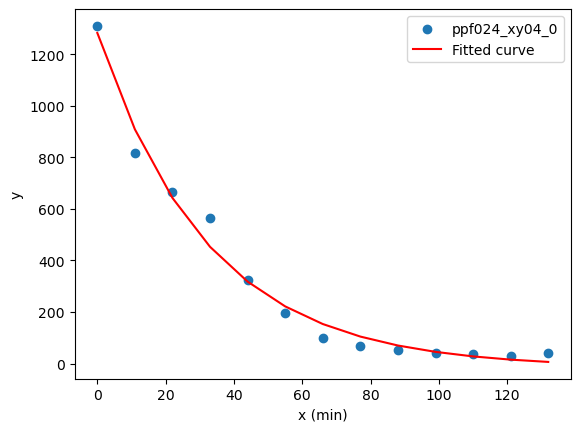

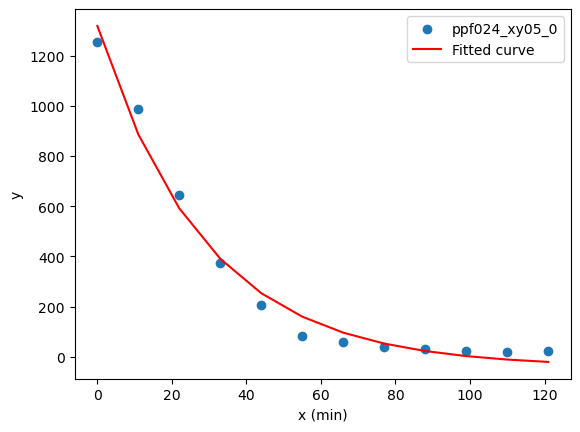

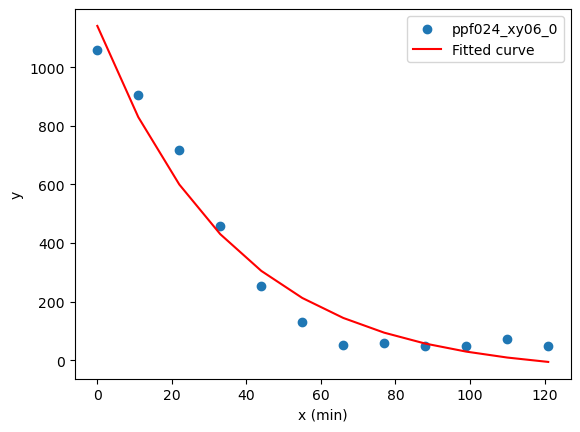

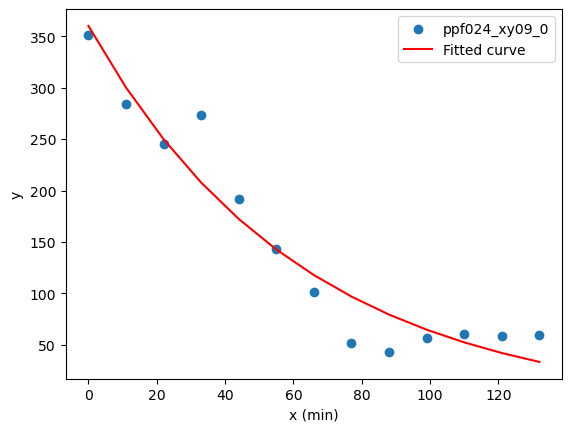

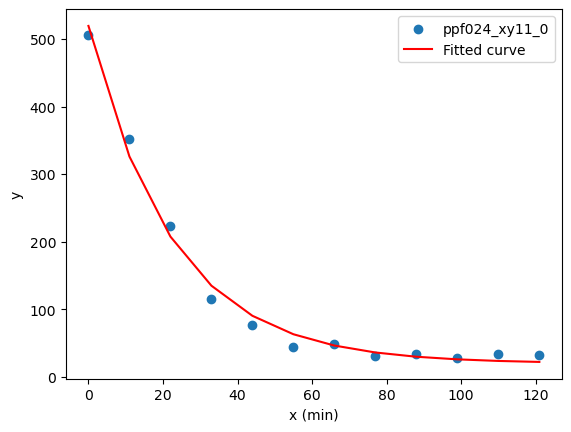

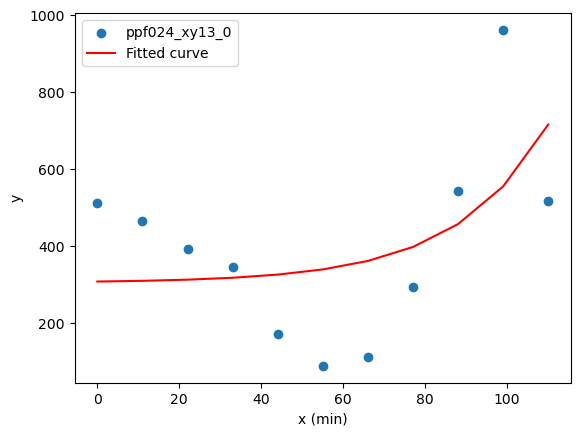

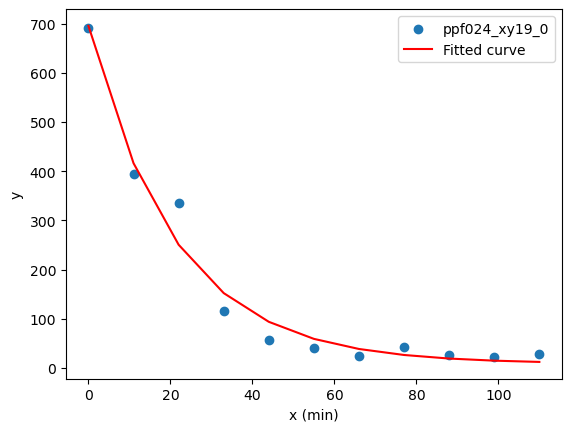

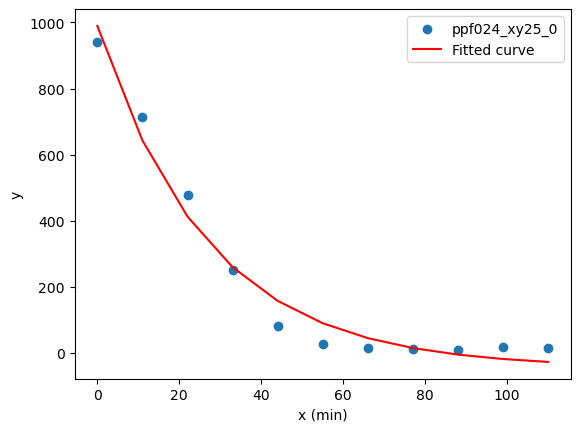

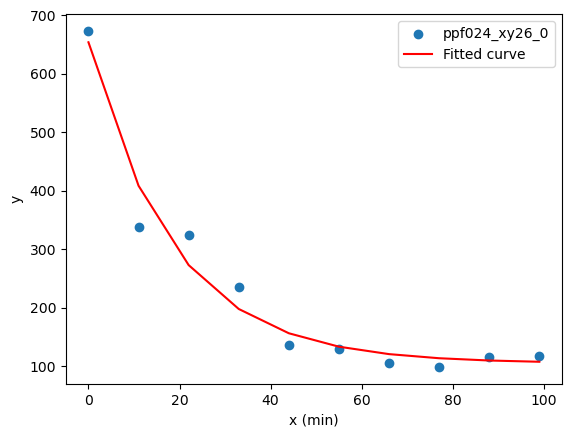

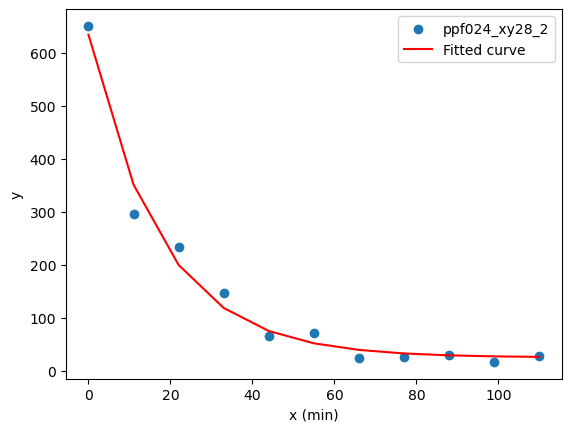

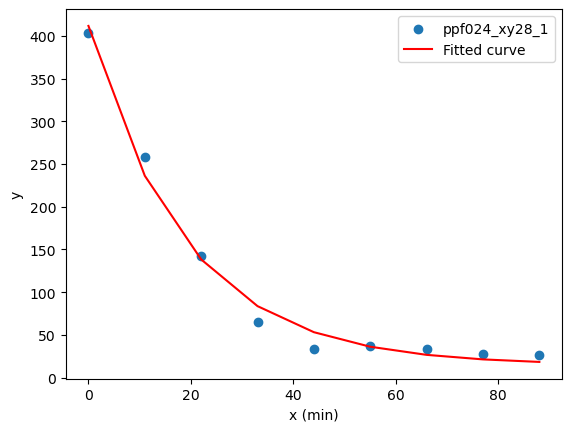

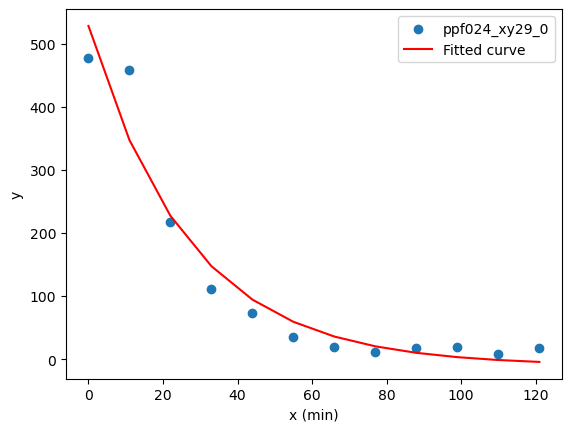

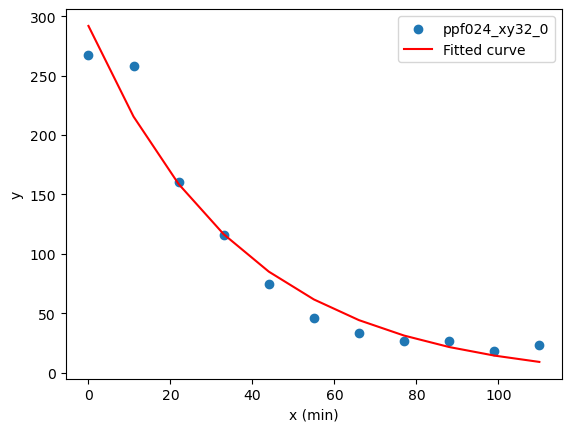

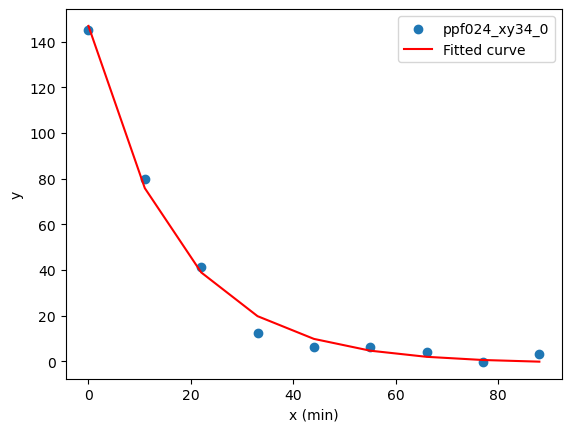

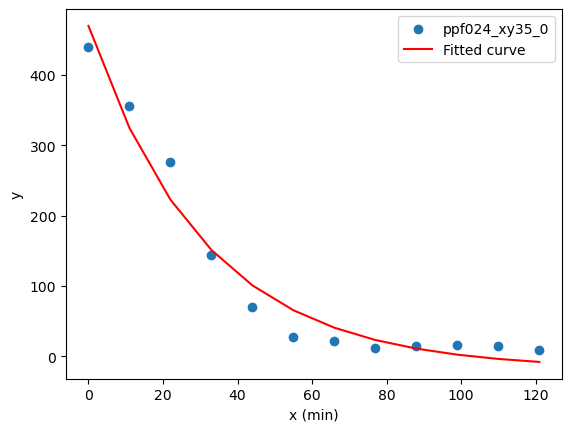

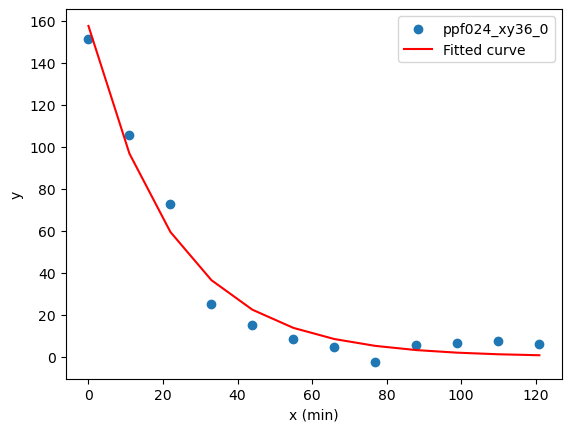

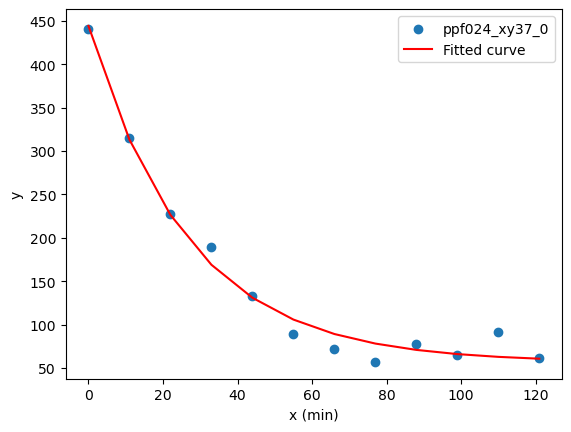

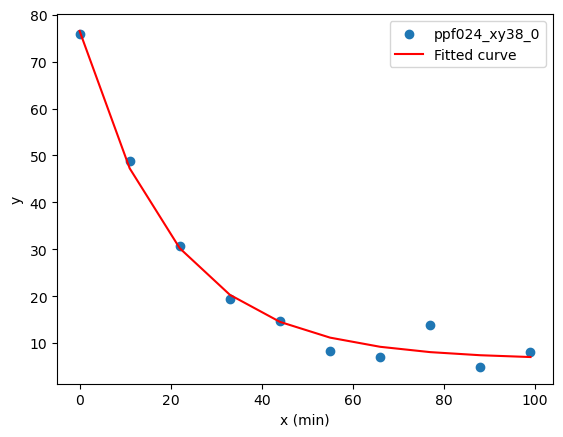

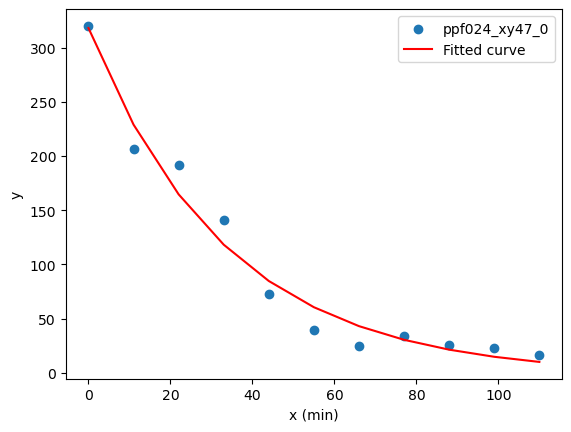

Not good parameters found


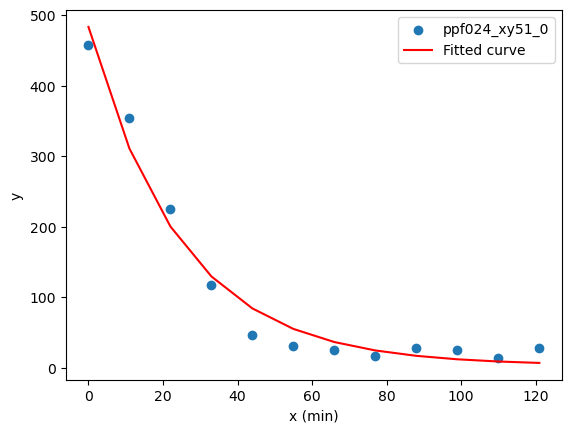

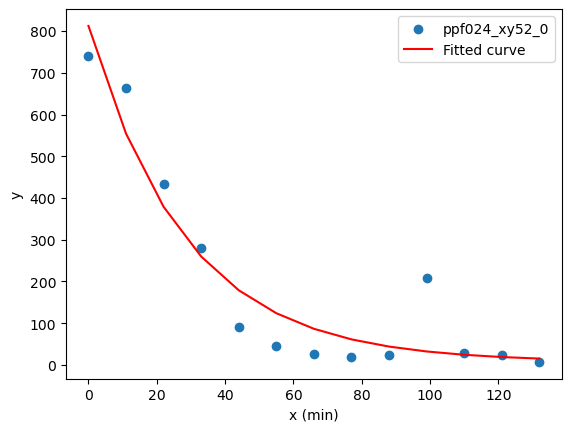

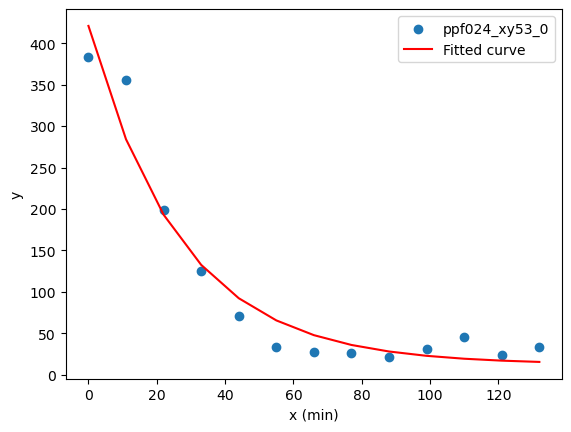

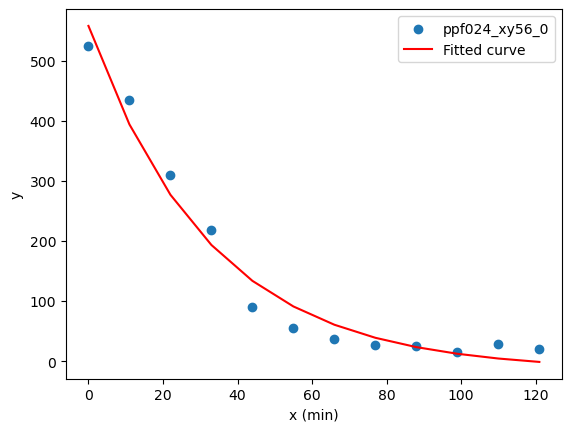

Not good parameters found


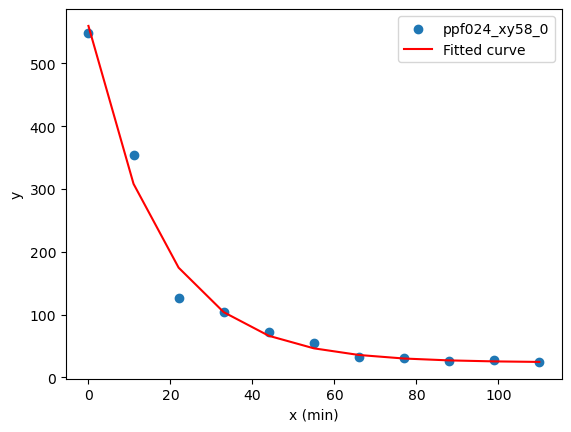

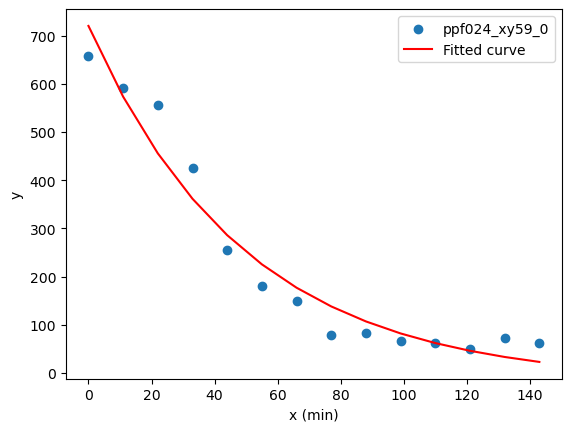

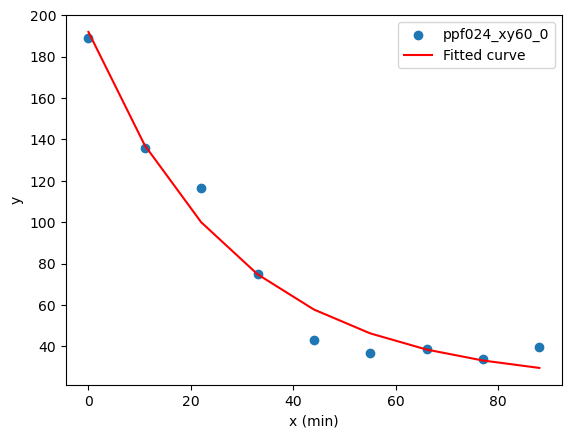

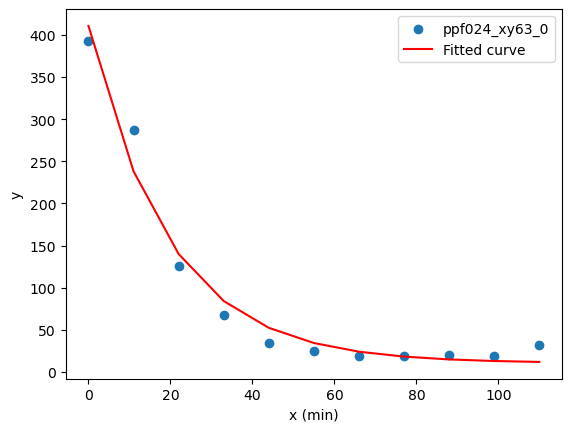

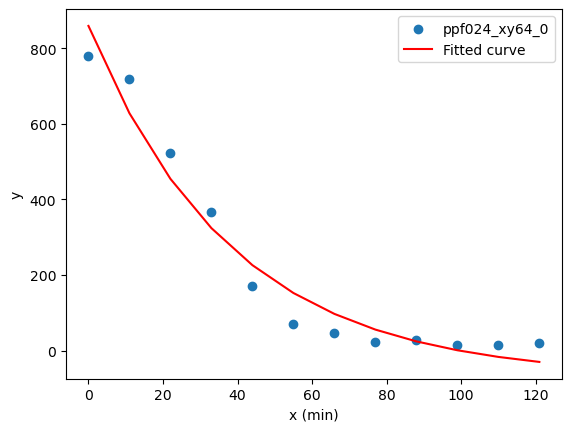

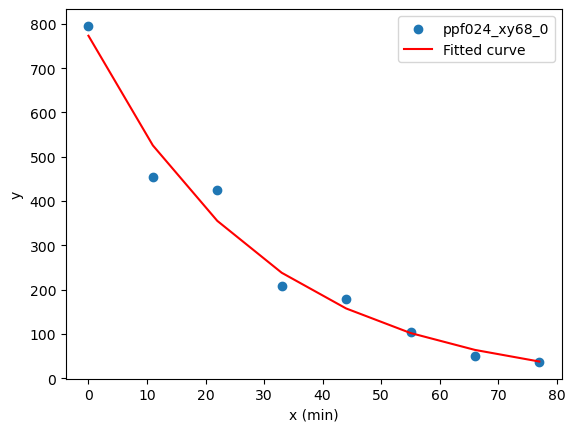

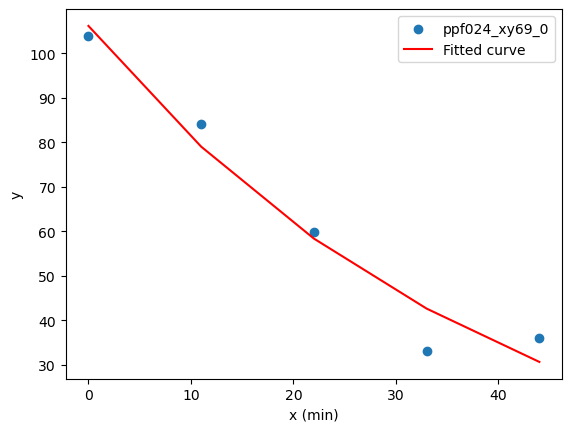

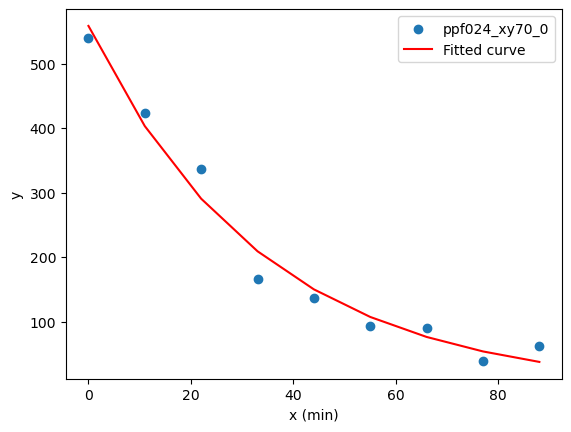

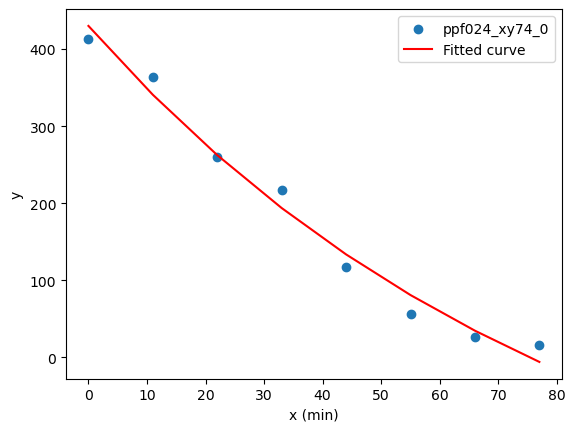

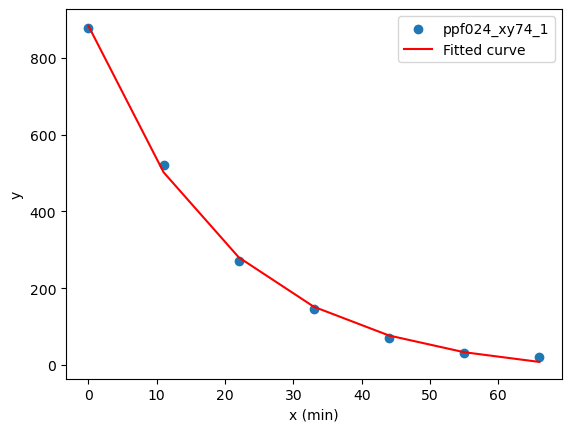

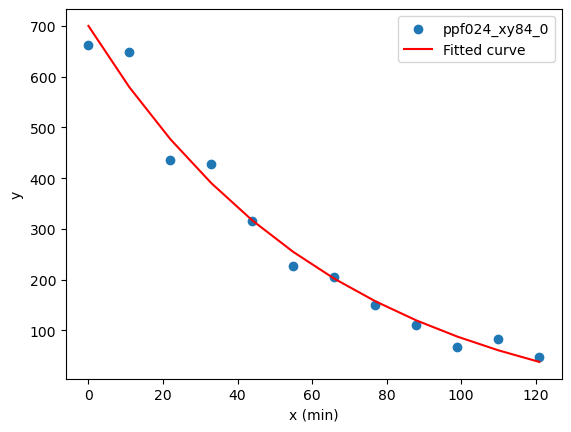

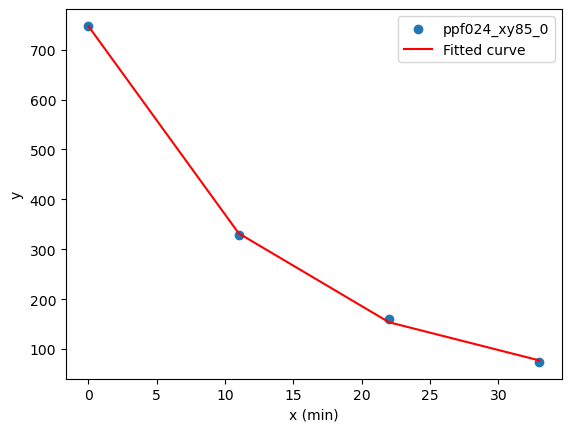

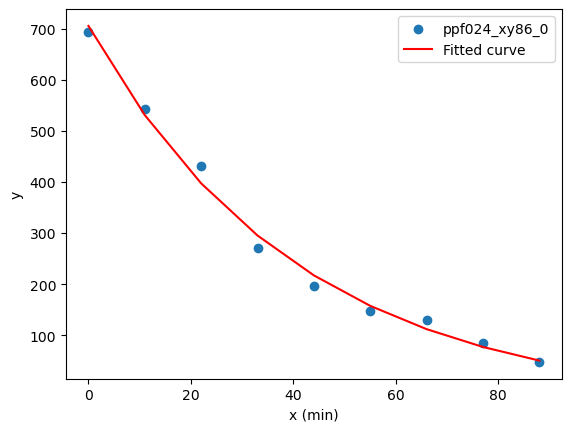

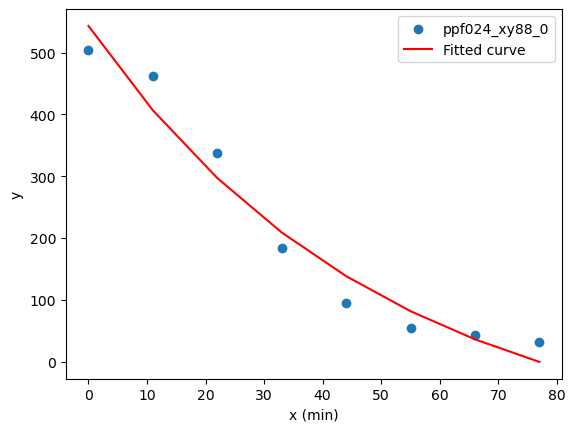

Not good parameters found


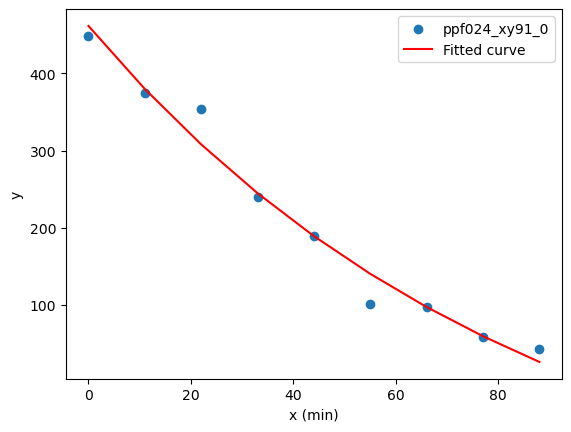

C:\Users\pperez\AppData\Local\Temp\14\ipykernel_51276\162203861.py:19: RuntimeWarning: overflow encountered in multiply
  return y_min + (y_max - y_min) * np.exp(-b * x)


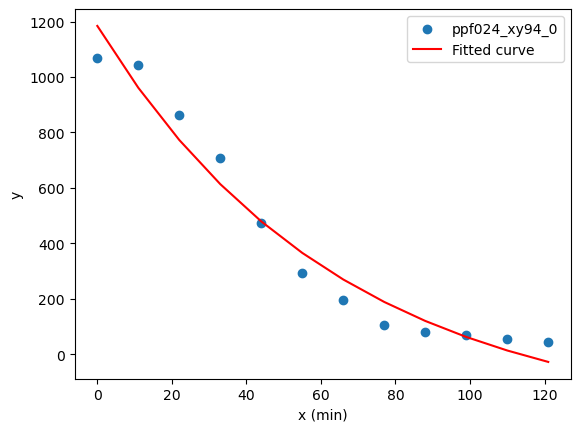

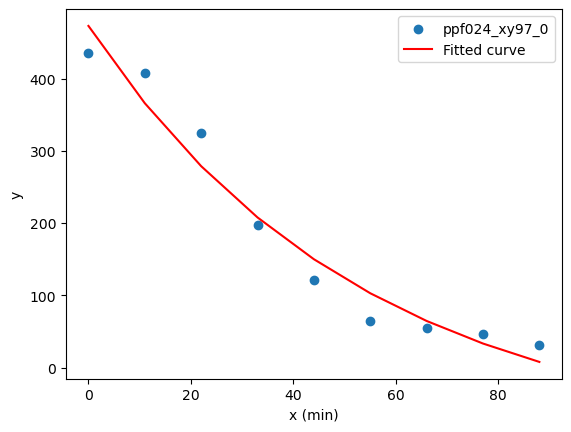

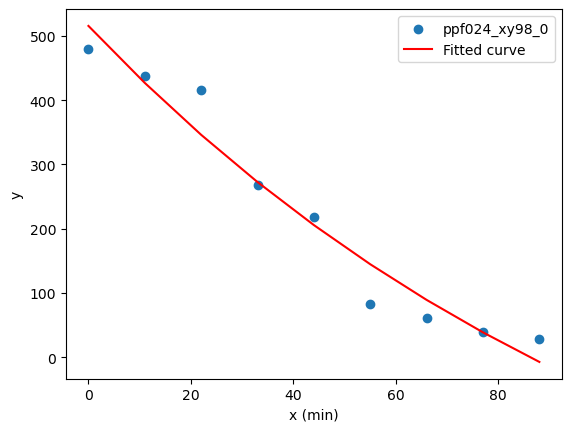

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def get_points(signal, traces, trimmed):
    peak = int(trimmed.loc[trimmed['Signal']==signal, 'Peak pos'].max())
    eo = int(trimmed.loc[trimmed['Signal']==signal, 'End of oscillation'].max())
    points = traces[signal][peak:eo+5]
    return points


signals_con_fit = trimmed.loc[(trimmed['Condition'] == 'Control'), 'Signal'].unique()
signals_40_fit = trimmed.loc[(trimmed['Condition'] == '40 nM'), 'Signal'].unique()
signals_80_fit = trimmed.loc[(trimmed['Condition'] == '80 nM'), 'Signal'].unique()

def exponential_decay(x, a, b):
    return a * np.exp(-b * x)
def modified_exponential_decay(x, y_min, y_max, b):
    return y_min + (y_max - y_min) * np.exp(-b * x)

# Initial guesses for the parameters
decay_list_control = []

for signal in signals_con_fit:
    y = get_points(signal, traces, trimmed)
    x = np.arange(0, len(y), 1)
    x_min = 11 * x
    initial_guess = [min(y), max(y), 1]
    try:
        params, covariance = curve_fit(modified_exponential_decay, x_min, y)
        plateau, peak_s, decay_rate = params
        decay_list_control.append(decay_rate)
        plt.scatter(x_min, y, label=signal)
        plt.plot(x_min, modified_exponential_decay(x_min, *params), label='Fitted curve', color='red')
        plt.xlabel('x (min)')
        plt.ylabel('y')
        plt.legend()
        plt.show()
    except RuntimeError:
        print('Not good parameters found')
    except TypeError:
        print('Not enough data')

decay_list_40 = []

for signal in signals_40_fit:
    y = get_points(signal, traces, trimmed)
    x = np.arange(0, len(y), 1)
    x_min = 11 * x
    initial_guess = [min(y), max(y), 1]
    try:
        params, covariance = curve_fit(modified_exponential_decay, x_min, y)
        plateau, peak_s, decay_rate = params
        decay_list_40.append(decay_rate)
        plt.scatter(x_min, y, label=signal)
        plt.plot(x_min, modified_exponential_decay(x_min, *params), label='Fitted curve', color='red')
        plt.xlabel('x (min)')
        plt.ylabel('y')
        plt.legend()
        plt.show()
    except RuntimeError:
        print('Not good parameters found')
    except TypeError:
        print('Not enough data')


def get_points(signal, traces, trimmed):
    peak = int(trimmed.loc[trimmed['Signal']==signal, 'Peak pos'].max())
    eo = int(trimmed.loc[trimmed['Signal']==signal, 'End of oscillation'].max())
    points = traces[signal][peak:eo+1]
    return points

decay_list_80 = []

for signal in signals_80_fit:
    y = get_points(signal, traces, trimmed)
    x = np.arange(0, len(y), 1)
    x_min = 11 * x
    initial_guess = [min(y), max(y), 1]
    try:
        params, covariance = curve_fit(modified_exponential_decay, x_min, y)
        plateau, peak_s, decay_rate = params
        decay_list_80.append(decay_rate)
        plt.scatter(x_min, y, label=signal)
        plt.plot(x_min, modified_exponential_decay(x_min, *params), label='Fitted curve', color='red')
        plt.xlabel('x (min)')
        plt.ylabel('y')
        plt.legend()
        plt.show()
    except RuntimeError:
        print('Not good parameters found')
    except TypeError:
        print('Not enough data')

In [5]:
decay_control_df = pd.DataFrame(decay_list_control)
decay_control_df['Condition'] = 'Control'
decay_40_df = pd.DataFrame(decay_list_40)
decay_40_df['Condition'] = '40 nM'
decay_80_df = pd.DataFrame(decay_list_80)
decay_80_df['Condition'] = '80 nM'
decay_df = pd.concat([decay_control_df, decay_40_df, decay_80_df], ignore_index=True)
decay_df.rename(columns={0:'decay_rate'}, inplace=True)

In [6]:
decay_df = decay_df[decay_df['decay_rate'] >=0]

In [7]:
decay_df['half-life'] = np.log(2)/decay_df['decay_rate']

In [11]:
decay_df_total = decay_df.copy()

In [10]:
p = bokeh_catplot.strip(
    data=decay_df,
    cats='Condition',
    val='decay_rate',
    horizontal=False,
    jitter=True,
    height=650,
    width=850,
    # tooltips=[('Position', '@{Cell_position}'),
    #          ('Period', '@{Max. power period (min)}')]
    
)

p = bokeh_catplot.box(
    data=decay_df,
    cats='Condition',
    val='decay_rate',
    horizontal=False,
    whisker_caps=True,
    display_points=False,
    box_kwargs=dict(fill_color=None, line_color='gray'),
    median_kwargs=dict(line_color='gray'),
    whisker_kwargs=dict(line_color='gray'),
    height=650,
    width=850,
    p=p,
)

bokeh.io.show(p)

C:\Users\pperez\.conda\envs\devbio-napari-cupy\lib\site-packages\bokeh\io\notebook.py:487: DeprecationWarning: The `source` parameter emit a  deprecation warning since IPython 8.0, it had no effects for a long time and will  be removed in future versions.
  publish_display_data(data, metadata, source, transient=transient, **kwargs)


In [14]:
p = bokeh_catplot.strip(
    data=decay_df_total.loc[(decay_df_total['Condition'] == 'Control') | (decay_df_total['Condition'] == '40 nM')| (decay_df_total['Condition'] == '80 nM'), :],
    cats=['Condition'],
    val='half-life',
    horizontal=False,
    jitter=True,
    height=650,
    width=850,
    x_range=(0, decay_df_total.loc[decay_df_total['Condition'] == '80 nM', 'half-life'].max()+5),
    marker_kwargs=dict(size=6,alpha=0.8)    # tooltips=[('Position', '@{Cell_position}'),
    #          ('Period', '@{Max. power period (min)}')]
    
)

p = bokeh_catplot.box(
    data=decay_df_total.loc[(decay_df_total['Condition'] == 'Control') | (decay_df_total['Condition'] == '40 nM')| (decay_df_total['Condition'] == '80 nM'), :],
    cats=['Condition'],
    val='half-life',
    horizontal=False,
    whisker_caps=True,
    display_points=False,
    box_kwargs=dict(fill_color=None, line_color='gray'),
    median_kwargs=dict(line_color='gray'),
    whisker_kwargs=dict(line_color='gray'),
    height=650,
    width=850,
    p=p,
)

mean_control = np.log(2)/(decay_df_total.loc[decay_df_total['Condition']=='Control', 'decay_rate'].mean())
median_control = np.log(2)/decay_df_total.loc[decay_df_total['Condition']=='Control', 'decay_rate'].median()
std_control = np.log(2)/(np.square(decay_df_total.loc[decay_df_total['Condition']=='Control', 'decay_rate'].mean())) * decay_df_total.loc[decay_df_total['Condition']=='Control', 'decay_rate'].std(ddof=1)

mean_40 = np.log(2)/(decay_df_total.loc[decay_df_total['Condition']=='40 nM', 'decay_rate'].mean())
median_40 = np.log(2)/decay_df_total.loc[decay_df_total['Condition']=='40 nM', 'decay_rate'].median()
std_40 = np.log(2)/(np.square(decay_df_total.loc[decay_df_total['Condition']=='40 nM', 'decay_rate'].mean())) * decay_df_total.loc[decay_df_total['Condition']=='40 nM', 'decay_rate'].std(ddof=1)

mean_80 = np.log(2)/(decay_df_total.loc[decay_df_total['Condition']=='80 nM', 'decay_rate'].mean())
median_80 = np.log(2)/decay_df_total.loc[decay_df_total['Condition']=='80 nM', 'decay_rate'].median()
std_80 = np.log(2)/(np.square(decay_df_total.loc[decay_df_total['Condition']=='80 nM', 'decay_rate'].mean())) * decay_df_total.loc[decay_df_total['Condition']=='80 nM', 'decay_rate'].std(ddof=1)

p.circle([], [], legend_label=f"Control:")
p.circle([], [], legend_label=f"Total signals: {len(decay_df_total.loc[decay_df_total['Condition']=='Control', 'half-life'])}")
p.circle([], [], legend_label=f"Mean: {mean_control:.0f} min")
p.circle([], [], legend_label=f"Median: {median_control:.0f} min")
p.circle([], [], legend_label=f"Std: {std_control:.0f} min",)

p.circle([], [], legend_label=f"------")

p.circle([], [], legend_label=f"40 nM CHX:")
p.circle([], [], legend_label=f"Total signals: {len(decay_df_total.loc[decay_df_total['Condition']=='40 nM', 'half-life'])}")
p.circle([], [], legend_label=f"Mean: {mean_40:.0f} mins")
p.circle([], [], legend_label=f"Median: {median_40:.0f} mins")
p.circle([], [], legend_label=f"Std: {std_40:.0f} mins")

p.circle([], [], legend_label=f"-------")

p.circle([], [], legend_label=f"80 nM CHX:")
p.circle([], [], legend_label=f"Total signals: {len(decay_df_total.loc[decay_df_total['Condition']=='80 nM', 'half-life'])}")
p.circle([], [], legend_label=f"Mean: {mean_80:.0f} min")
p.circle([], [], legend_label=f"Median: {median_80:.0f} min")
p.circle([], [], legend_label=f"Std: {std_80:.0f} min")

p.output_backend = "svg"
p.legend.title = 'Statistics'
p.legend.location = 'top_right'
p.legend.label_text_font_size = '12pt'
p.xaxis.axis_label = 'her1-Venus half-life (min)'
p.xaxis.axis_label_text_font_size='16pt'
p.xaxis.major_label_text_font_size = '14pt'
p.yaxis.major_label_text_font_size  = '16pt'
# export_svgs(p, filename="./half-life.svg")
bokeh.io.show(p)

C:\Users\pperez\.conda\envs\devbio-napari-cupy\lib\site-packages\bokeh\io\notebook.py:487: DeprecationWarning: The `source` parameter emit a  deprecation warning since IPython 8.0, it had no effects for a long time and will  be removed in future versions.
  publish_display_data(data, metadata, source, transient=transient, **kwargs)


In [62]:
decay_df.reset_index(inplace=True)

In [65]:
decay_df.drop('index', axis=1, inplace=True)

In [66]:
decay_df.to_csv('decay_rates_ppf018')

In [49]:
decay_df.drop(index_to_remove, inplace=True)

In [8]:
decay_df['Exp'] = 'ppf021'

In [19]:
decay_df.to_csv('decay_rates_ppf021')

In [24]:
decay_df

,decay_rate,Condition,half-life,Exp
0,0.026347,Control,26.308059,ppf021
1,0.029206,Control,23.733318,ppf021
2,0.034069,Control,20.345640,ppf021
3,0.031717,Control,21.854354,ppf021
4,0.017609,Control,39.363263,ppf021
...,...,...,...,...
63,0.018931,80 nM,36.615137,ppf021
64,0.024070,80 nM,28.796952,ppf021
65,0.014311,80 nM,48.435544,ppf021
66,0.022335,80 nM,31.033604,ppf021


In [9]:
# Function to remove outliers based on Tukey's fences for each group
def remove_outliers_grouped(df, column, group_column):
    def filter_outliers(group):
        Q1 = group[column].quantile(0.25)
        Q3 = group[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        return group[(group[column] >= lower_bound) & (group[column] <= upper_bound)]
    
    # Apply filtering function to each group
    return df.groupby(group_column, group_keys=False).apply(filter_outliers)

# Remove outliers from the 'half-life' column grouped by 'Condition'
cleaned_df = remove_outliers_grouped(decay_df, column='half-life', group_column='Condition')

# Output the cleaned dataset
print("Cleaned Dataset:")
print(cleaned_df)

Cleaned Dataset:
    decay_rate Condition  half-life     Exp
13    0.059564     40 nM  11.637084  ppf021
14    0.032094     40 nM  21.597415  ppf021
15    0.044324     40 nM  15.638060  ppf021
16    0.037521     40 nM  18.473395  ppf021
17    0.049229     40 nM  14.079940  ppf021
18    0.029638     40 nM  23.387244  ppf021
19    0.040489     40 nM  17.119457  ppf021
20    0.035151     40 nM  19.719255  ppf021
21    0.037079     40 nM  18.694007  ppf021
22    0.030620     40 nM  22.636777  ppf021
23    0.057578     40 nM  12.038484  ppf021
25    0.035427     40 nM  19.565284  ppf021
26    0.051281     40 nM  13.516697  ppf021
27    0.025997     40 nM  26.662960  ppf021
28    0.034004     80 nM  20.384001  ppf021
29    0.024763     80 nM  27.991364  ppf021
30    0.029309     80 nM  23.649341  ppf021
31    0.011982     80 nM  57.849664  ppf021
32    0.049334     80 nM  14.050190  ppf021
33    0.015144     80 nM  45.769963  ppf021
34    0.076913     80 nM   9.012083  ppf021
35    0.024418 

In [10]:
decay_df_total = cleaned_df.copy()

In [28]:
decay_df_total

,decay_rate,Condition,half-life,Exp
20,0.029451,40 nM,23.535749,ppf021
21,0.041123,40 nM,16.855369,ppf021
23,0.027658,40 nM,25.061676,ppf021
24,0.020317,40 nM,34.116623,ppf021
25,0.020451,40 nM,33.893721,ppf021
...,...,...,...,...
14,0.042840,Control,16.179725,ppf021
15,0.034412,Control,20.142606,ppf021
16,0.022429,Control,30.904179,ppf021
17,0.031748,Control,21.832883,ppf021


In [16]:
cleaned_df.to_csv('decay_rates_ppf024')

In [15]:
cleaned_df['Exp'] = 'ppf024'